# pips

In [1]:
! pip install fuzzywuzzy python-Levenshtein

In [2]:
! pip install scikit-bio

In [3]:
! pip install statsmodels

In [4]:
! pip install plotly

In [5]:
! pip install nbformat

# imports

In [6]:
import pandas as pd
import os
import re
from fuzzywuzzy import process
from pprint import pprint
import numpy as np
#from skbio.diversity.alpha import shannon, simpson
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from skbio.stats.ordination import pcoa
from skbio.diversity import beta_diversity
from skbio.stats.distance import permanova
from skbio.diversity.alpha import chao1
import plotly.express as px
import plotly.io as pio

In [7]:
os.getcwd()

'c:\\Users\\ADMIN\\Desktop\\Barcelona Activa\\Bootcamp\\Especializacion mentorizada\\Sprint 13-Proyecto final'

# Cargar datos y seleccionar columas:

In [8]:
config_archivos ={
    "AN17A_ AN18A.xlsx": {"ID_field": "id_captura", "Day": "fecha", "Species": "especie", "Station": "localidad"},
    "AN18B.xlsx": {"ID": "id_captura", "Day": "fecha", "Bird Species": "especie", "Loc.": "localidad"},
    "AN19A.xlsx": {"No.": "id_captura", "Day": "fecha", "Unnamed: 9": "especie", "Loc.": "localidad"},
    "AN19B.xlsx": {"ID": "id_captura", "Day": "fecha", "Species": "especie", "Estacion ": "localidad"}}

dfs = {}

for archivo, mapeo in config_archivos.items():
    pre_df = pd.read_excel(archivo, usecols=list(mapeo.keys())).rename(columns=mapeo)
    
    nombre_archivos= archivo.replace(".xlsx", "")
    dfs[nombre_archivos] = pre_df


display(dfs["AN17A_ AN18A"].head(5))
display(dfs["AN18B"].head(5))
display(dfs["AN19A"].head(5))
display(dfs["AN19B"].head(5))

,id_captura,fecha,especie,localidad
0,1,2017-06-15,Phaethornis yaruqui,La loca
1,2,2017-06-15,Doryfera ludovicae,La loca
2,3,2017-06-15,Euphonia xanthogaster,La loca
3,4,2017-06-15,Microbates cinereiventris,La loca
4,5,2017-06-15,Bangsia rothschildi,La loca


,id_captura,fecha,especie,localidad
0,23,2018-11-08,Microbates cinereiventris,Loca 1
1,25,2018-11-08,Campylorhamphus pusillus,Loca 1
2,28,2018-11-08,Eutoxeres aquila,Loca 1
3,30,2018-11-08,Phaethornis yaruqui,Loca 1
4,32,2018-11-08,Formicarius nigricapillus,Loca 1


,id_captura,fecha,especie,localidad
0,1,2019-03-08,Xiphorhynchus erythropygius,Loca 1
1,2,2019-03-08,Bangsia rothschildi,Loca 1
2,3,2019-03-08,Dixiphia pipra,Loca 1
3,4,2019-03-08,Gymnopithys bicolor,Loca 1
4,5,2019-03-08,Mionectes olivaceus,Loca 1


,id_captura,fecha,localidad,especie
0,1,2019-09-17,La Batea,Threnetes ruckeri
1,2,2019-09-17,La Batea,Baryphthengus martii
2,3,2019-09-17,La Batea,Microbates cinereiventris
3,4,2019-09-17,La Batea,Mionectes olivaceus
4,5,2019-09-17,La Batea,Phaethornis yaruqui


# eliminacion de años con una sola vuelta (2017):

In [9]:
df_mixto = dfs["AN17A_ AN18A"]
dfs["AN18A"] = df_mixto[df_mixto['fecha'].dt.year == 2018].copy()
del dfs["AN17A_ AN18A"]
display(dfs["AN18A"].head(15))

display(dfs["AN18A"].info())


,id_captura,fecha,especie,localidad
669,1,2018-03-24,Phaenostictus mcleannani,La Loca 3
670,2,2018-03-24,Phaethornis yaruqui,La Loca 3
671,3,2018-03-24,Phaethornis yaruqui,La Loca 3
672,4,2018-03-24,Dixiphia pipra,La Loca 3
673,5,2018-03-24,Glyphorynchus spirurus,La Loca 3
674,6,2018-03-24,Automolus subulatus,La Loca 3
675,7,2018-03-24,Dixiphia pipra,La Loca 3
676,8,2018-03-24,Phaethornis yaruqui,La Loca 3
677,9,2018-03-24,Schiffornis veraepacis,La Loca 3
678,10,2018-03-24,Glyphorynchus spirurus,La Loca 3


<class 'pandas.core.frame.DataFrame'>
Index: 816 entries, 669 to 1484
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id_captura  816 non-null    int64         
 1   fecha       816 non-null    datetime64[ns]
 2   especie     816 non-null    object        
 3   localidad   816 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 31.9+ KB


None

# estandarizacion del id:

In [10]:
dfs["AN18A"].insert(0, "id_unificado", "AN18A" + dfs["AN18A"]["id_captura"].astype(str))
dfs["AN18B"].insert(0, "id_unificado", "AN18B" + dfs["AN18B"]["id_captura"].astype(str))
dfs["AN19A"].insert(0, "id_unificado", "AN19A" + dfs["AN19A"]["id_captura"].astype(str))
dfs["AN19B"].insert(0, "id_unificado", "AN19B" + dfs["AN19B"]["id_captura"].astype(str))

display(dfs["AN18A"].head(5))
display(dfs["AN18B"].head(5))
display(dfs["AN19A"].head(5))
display(dfs["AN19B"].head(5))

,id_unificado,id_captura,fecha,especie,localidad
669,AN18A1,1,2018-03-24,Phaenostictus mcleannani,La Loca 3
670,AN18A2,2,2018-03-24,Phaethornis yaruqui,La Loca 3
671,AN18A3,3,2018-03-24,Phaethornis yaruqui,La Loca 3
672,AN18A4,4,2018-03-24,Dixiphia pipra,La Loca 3
673,AN18A5,5,2018-03-24,Glyphorynchus spirurus,La Loca 3


,id_unificado,id_captura,fecha,especie,localidad
0,AN18B23,23,2018-11-08,Microbates cinereiventris,Loca 1
1,AN18B25,25,2018-11-08,Campylorhamphus pusillus,Loca 1
2,AN18B28,28,2018-11-08,Eutoxeres aquila,Loca 1
3,AN18B30,30,2018-11-08,Phaethornis yaruqui,Loca 1
4,AN18B32,32,2018-11-08,Formicarius nigricapillus,Loca 1


,id_unificado,id_captura,fecha,especie,localidad
0,AN19A1,1,2019-03-08,Xiphorhynchus erythropygius,Loca 1
1,AN19A2,2,2019-03-08,Bangsia rothschildi,Loca 1
2,AN19A3,3,2019-03-08,Dixiphia pipra,Loca 1
3,AN19A4,4,2019-03-08,Gymnopithys bicolor,Loca 1
4,AN19A5,5,2019-03-08,Mionectes olivaceus,Loca 1


,id_unificado,id_captura,fecha,localidad,especie
0,AN19B1,1,2019-09-17,La Batea,Threnetes ruckeri
1,AN19B2,2,2019-09-17,La Batea,Baryphthengus martii
2,AN19B3,3,2019-09-17,La Batea,Microbates cinereiventris
3,AN19B4,4,2019-09-17,La Batea,Mionectes olivaceus
4,AN19B5,5,2019-09-17,La Batea,Phaethornis yaruqui


# union de los dfs en uno solo:

In [11]:
main_df= pd.concat(dfs.values(), ignore_index=True)

display(main_df.head())
display(main_df.tail())
display(main_df.info())


,id_unificado,id_captura,fecha,especie,localidad
0,AN18B23,23,2018-11-08,Microbates cinereiventris,Loca 1
1,AN18B25,25,2018-11-08,Campylorhamphus pusillus,Loca 1
2,AN18B28,28,2018-11-08,Eutoxeres aquila,Loca 1
3,AN18B30,30,2018-11-08,Phaethornis yaruqui,Loca 1
4,AN18B32,32,2018-11-08,Formicarius nigricapillus,Loca 1


,id_unificado,id_captura,fecha,especie,localidad
2340,AN18A813,813,2018-06-07,Myiothlypis fulvicauda,Riqueza 2 (bajo)
2341,AN18A814,814,2018-06-07,Phaethornis yaruqui,Riqueza 2 (bajo)
2342,AN18A815,815,2018-06-07,Heliodoxa jacula,Riqueza 2 (bajo)
2343,AN18A816,816,2018-06-07,Mionectes olivaceus,Riqueza 2 (bajo)
2344,AN18A817,817,2018-06-07,Doryfera ludovicae,Riqueza 2 (bajo)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2345 entries, 0 to 2344
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_unificado  2345 non-null   object        
 1   id_captura    2345 non-null   int64         
 2   fecha         2343 non-null   datetime64[ns]
 3   especie       2343 non-null   object        
 4   localidad     2343 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 91.7+ KB


None

# Limpieza:


In [12]:
#en info() se ve que los id tienen 2345 filas pero el resto de columnas tienen 2343 -->buscar y limpiar
filas_nulas = main_df[main_df["especie"].isna()]
display(filas_nulas)

main_df = main_df.dropna(subset=["especie"])

main_df= main_df[main_df["especie"] != "passer domesticus"]

main_df.info()

,id_unificado,id_captura,fecha,especie,localidad
341,AN19A12,12,NaT,NaN,NaN
343,AN19A13,13,NaT,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
Index: 2343 entries, 0 to 2344
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_unificado  2343 non-null   object        
 1   id_captura    2343 non-null   int64         
 2   fecha         2343 non-null   datetime64[ns]
 3   especie       2343 non-null   object        
 4   localidad     2343 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 109.8+ KB


In [13]:

main_df[main_df["especie"] == "ramphocelus flammigerus icteronotus"]

,id_unificado,id_captura,fecha,especie,localidad


## Quitar los sp y los cf

In [14]:
print(f"num registros: {len(main_df)}")

patrones_a_eliminar = r"\bsp\b|\bcf\b|\bc.f\b|no existe|americanus|ramphocelus flammigerus icteronotus"

# para saber que es lo q se va a quitar
eliminados_df = main_df[main_df['especie'].str.contains(patrones_a_eliminar, case=False, na=False, regex=True)]

print("Especies que serán eliminadas:")
print(eliminados_df['especie'].unique())

#cuántas filas se quitan de cada una
print("\nConteo por etiqueta eliminada:")
print(eliminados_df['especie'].value_counts())

# ejecutar para aplicar (con la tilde ~)
main_df = main_df[~main_df['especie'].str.contains(patrones_a_eliminar, case=False, na=False, regex=True)]

print(f"Registros después: {len(main_df)}")


num registros: 2343
Especies que serán eliminadas:
['Scytalopus chocoensis cf' 'No existe captura' 'Thamnistes anabatinus cf'
 'Ramphocelus flammigerus icteroNotus' 'Automolus sp'
 'Empidonax virescens c.f' 'Turdus sp' 'americanus' 'Henicorhina cf'
 'Empidonax sp.' 'Sporophila sp.' 'Manakin cf']

Conteo por etiqueta eliminada:
especie
Henicorhina cf                         2
Automolus sp                           2
Scytalopus chocoensis cf               1
No existe captura                      1
Ramphocelus flammigerus icteroNotus    1
Thamnistes anabatinus cf               1
Turdus sp                              1
Empidonax virescens c.f                1
americanus                             1
Empidonax sp.                          1
Sporophila sp.                         1
Manakin cf                             1
Name: count, dtype: int64
Registros después: 2329


## quitar espacios (inicio, final e intermedios) y mayusculas


In [15]:
main_df['especie'] = main_df['especie'].str.lower().str.replace(r'\s+', ' ', regex=True).str.strip()

main_df["localidad"] = main_df["localidad"].str.lower().str.strip()

main_df

,id_unificado,id_captura,fecha,especie,localidad
0,AN18B23,23,2018-11-08,microbates cinereiventris,loca 1
1,AN18B25,25,2018-11-08,campylorhamphus pusillus,loca 1
2,AN18B28,28,2018-11-08,eutoxeres aquila,loca 1
3,AN18B30,30,2018-11-08,phaethornis yaruqui,loca 1
4,AN18B32,32,2018-11-08,formicarius nigricapillus,loca 1
...,...,...,...,...,...
2340,AN18A813,813,2018-06-07,myiothlypis fulvicauda,riqueza 2 (bajo)
2341,AN18A814,814,2018-06-07,phaethornis yaruqui,riqueza 2 (bajo)
2342,AN18A815,815,2018-06-07,heliodoxa jacula,riqueza 2 (bajo)
2343,AN18A816,816,2018-06-07,mionectes olivaceus,riqueza 2 (bajo)


## separar columna fecha en dia-mes-año y ordenar

In [16]:
main_df.insert(2,"dia",main_df["fecha"].dt.day)
main_df.insert(3,"mes",main_df["fecha"].dt.month)
main_df.insert(4,"año",main_df["fecha"].dt.year)


#ordenar por año
main_df = main_df.sort_values(by=["año","mes","id_captura"]).reset_index(drop=True)

display(main_df.head(15))



,id_unificado,id_captura,dia,mes,año,fecha,especie,localidad
0,AN18A1,1,24,3,2018,2018-03-24,phaenostictus mcleannani,la loca 3
1,AN18A2,2,24,3,2018,2018-03-24,phaethornis yaruqui,la loca 3
2,AN18A3,3,24,3,2018,2018-03-24,phaethornis yaruqui,la loca 3
3,AN18A4,4,24,3,2018,2018-03-24,dixiphia pipra,la loca 3
4,AN18A5,5,24,3,2018,2018-03-24,glyphorynchus spirurus,la loca 3
5,AN18A6,6,24,3,2018,2018-03-24,automolus subulatus,la loca 3
6,AN18A7,7,24,3,2018,2018-03-24,dixiphia pipra,la loca 3
7,AN18A8,8,24,3,2018,2018-03-24,phaethornis yaruqui,la loca 3
8,AN18A9,9,24,3,2018,2018-03-24,schiffornis veraepacis,la loca 3
9,AN18A10,10,24,3,2018,2018-03-24,glyphorynchus spirurus,la loca 3


In [17]:
main_df.duplicated().sum() #molt be no hay duplicados entonces pa lante

np.int64(0)

## Unificación de los nombres de las especies

In [18]:
pprint(sorted(main_df['especie'].unique()))

main_df["especie"].nunique()

['aglaiocercus coelestis',
 'amazilia amabilis',
 'amazilia rosembergii',
 'amazilia rosenbergi',
 'amazilia tzacatl',
 'androdon aequatorialis',
 'arremon atricapillus',
 'arremon aurantiirostris',
 'arremon aurantirostris',
 'attila spadiceus',
 'aulacorhynchus haematopygus',
 'automolus ochrolaemus',
 'automolus subulatus',
 'bangsia rothschildi',
 'baryphthengus martii',
 'cacicus uropigyalis',
 'cacicus uropygialis',
 'campylorhamphus pusillus',
 'cantorchilus nigricapillus',
 'capito maculicoronatus',
 'catharus ustulatus',
 'celeus loricatus',
 'chloroceryle americana',
 'chlorophanes spiza',
 'chlorospingus canigularis',
 'chlorospingus flavigularis',
 'chlorothraupis olivacea',
 'chlorothraupis stolzmanni',
 'chrysothlypis salmoni',
 'ciccaba virgata',
 'cichlopsis leucogenys',
 'claravis pretiosa',
 'clibanornis rubiginosus',
 'clivernornis rubiginosus',
 'coereba flaveola',
 'contopus cinereus',
 'cryptopipo holochlora',
 'cyanoloxa cyanoides',
 'cyanoloxia cyanoides',
 'den

133

### codigo de exploracion y prueba

In [19]:
''' ### con este codigo hice el fuzzy para generar los listados de las especies y verificar cuales cambiaba y cuales no############
############ codigo de exploracion#############################


frecuencias = main_df['especie'].value_counts() #reemember que el v_C te da una seria nombre sp--> # veces que aparece
nombres_unicos = frecuencias.index.tolist() #convertir la serie en lista para iterar

def mapeo_frecuencia(lista, counts, umbral=90):
    mapeo = {}
    procesados = set()
    
    nombres_ordenados = sorted(lista, key=lambda x: counts[x], reverse=True)

    for mejor_nombre in nombres_ordenados:
        if mejor_nombre in procesados:
            continue

        coincidencias = process.extract(mejor_nombre, lista, limit=10) #busca nombres que se parezcan al "mejor_nombre"
        
        for candidato, score in coincidencias:
            if candidato == mejor_nombre or candidato in procesados:
                continue
            if score >= umbral:
                mapeo[candidato] = mejor_nombre
                procesados.add(candidato)
    return mapeo


# modificaciones realizadas:
dict_correciones = mapeo_frecuencia(nombres_unicos, frecuencias)

print("---  CAMBIOS ---")
if not dict_correciones:
    print("Todo limpio.")
else:
    for error, correcto in dict_correciones.items():
        print(f"Cambiando: '{error}' (que aparece {frecuencias[error]} veces)")
        print(f"      por: '{correcto}' (que aparece {frecuencias[correcto]} veces)")
        print("-" * 30)

# Solo si después de ver la lista estás de acuerdo, corres esta línea:
# main_df['especie'] = main_df['especie'].replace(dict_correciones)'''

' ### con este codigo hice el fuzzy para generar los listados de las especies y verificar cuales cambiaba y cuales no############\n############ codigo de exploracion#############################\n\n\nfrecuencias = main_df[\'especie\'].value_counts() #reemember que el v_C te da una seria nombre sp--> # veces que aparece\nnombres_unicos = frecuencias.index.tolist() #convertir la serie en lista para iterar\n\ndef mapeo_frecuencia(lista, counts, umbral=90):\n    mapeo = {}\n    procesados = set()\n\n    nombres_ordenados = sorted(lista, key=lambda x: counts[x], reverse=True)\n\n    for mejor_nombre in nombres_ordenados:\n        if mejor_nombre in procesados:\n            continue\n\n        coincidencias = process.extract(mejor_nombre, lista, limit=10) #busca nombres que se parezcan al "mejor_nombre"\n\n        for candidato, score in coincidencias:\n            if candidato == mejor_nombre or candidato in procesados:\n                continue\n            if score >= umbral:\n           

In [20]:
'''############ codigo de exploracion#############################

with open("revision_taxonomica_90.txt", "w") as f:
    f.write("RESUMEN DE CAMBIOS TAXONÓMICOS al 90\n")
    f.write("="*30 + "\n")
    for error, correcto in dict_correciones.items():
        linea = f"Cambiando: {error} ({frecuencias[error]}) -> {correcto} ({frecuencias[correcto]})\n"
        f.write(linea)

print("Se ha creado el archivo, revisar la carpeta.")'''

'############ codigo de exploracion#############################\n\nwith open("revision_taxonomica_90.txt", "w") as f:\n    f.write("RESUMEN DE CAMBIOS TAXONÓMICOS al 90\n")\n    f.write("="*30 + "\n")\n    for error, correcto in dict_correciones.items():\n        linea = f"Cambiando: {error} ({frecuencias[error]}) -> {correcto} ({frecuencias[correcto]})\n"\n        f.write(linea)\n\nprint("Se ha creado el archivo, revisar la carpeta.")'

### correccion de typos en spp

In [21]:
frecuencias = main_df['especie'].value_counts() #reemember que el v_C te da una seria nombre sp--> # veces que aparece
nombres_unicos = frecuencias.index.tolist() #convertir la serie en lista para iterar

#lista de cambios que no se deben realizar porque son especies diferentes
excepciones_prohibidas = [
    ("manacus manacus", "manacus vitellinus"),
    ("chlorospingus canigularis", "chlorospingus flavigularis")]

#diccionario de cambios que se detectaron por fuera del umbral de 90
correcciones_adicionales = {
    "schiphorniis verapacis": "schiffornis veraepacis",
    "mitrospingus casinii": "mitrospingus cassinii",
    "clivernornis rubiginosus": "clibanornis rubiginosus",
    "cyanoloxa cyanoides": "cyanoloxia cyanoides",
    "cacicus uropigyalis": "cacicus uropygialis"}

def mapeo_frecuencia(lista, counts, umbral=90):
    mapeo = correcciones_adicionales.copy()
    procesados = set(mapeo.keys())
    nombres_ordenados = sorted(lista, key=lambda x: counts[x], reverse=True)

    for mejor_nombre in nombres_ordenados:
        if mejor_nombre in procesados:
            continue

        coincidencias = process.extract(mejor_nombre, lista, limit=10)
        
        for candidato, score in coincidencias:
            # Reglas de exclusión: no compararse consigo mismo ni con nombres ya corregidos
            if candidato == mejor_nombre or candidato in procesados:
                continue
            
            # REGLA 1: Verificar si esta pareja está en la LISTA NEGRA
            if (candidato, mejor_nombre) in excepciones_prohibidas or \
               (mejor_nombre, candidato) in excepciones_prohibidas:
                continue

            # REGLA 2: Si el parecido es >= 90, se considera error de dedo y se guarda
            if score >= umbral:
                mapeo[candidato] = mejor_nombre
                procesados.add(candidato)
                
    return mapeo

# modificaciones realizadas:
dict_correciones = mapeo_frecuencia(nombres_unicos, frecuencias)

print("---  CAMBIOS ---")
if not dict_correciones:
    print("Todo limpio.")
else:
    for error, correcto in dict_correciones.items():
        print(f"Cambiando: '{error}' (que aparece {frecuencias[error]} veces)")
        print(f"      por: '{correcto}' (que aparece {frecuencias[correcto]} veces)")
        print("-" * 30)

---  CAMBIOS ---
Cambiando: 'schiphorniis verapacis' (que aparece 9 veces)
      por: 'schiffornis veraepacis' (que aparece 42 veces)
------------------------------
Cambiando: 'mitrospingus casinii' (que aparece 1 veces)
      por: 'mitrospingus cassinii' (que aparece 37 veces)
------------------------------
Cambiando: 'clivernornis rubiginosus' (que aparece 1 veces)
      por: 'clibanornis rubiginosus' (que aparece 5 veces)
------------------------------
Cambiando: 'cyanoloxa cyanoides' (que aparece 1 veces)
      por: 'cyanoloxia cyanoides' (que aparece 3 veces)
------------------------------
Cambiando: 'cacicus uropigyalis' (que aparece 1 veces)
      por: 'cacicus uropygialis' (que aparece 2 veces)
------------------------------
Cambiando: 'tachiphonus delatrii' (que aparece 1 veces)
      por: 'tachyphonus delatrii' (que aparece 107 veces)
------------------------------
Cambiando: 'myiothlipis fulvicauda' (que aparece 2 veces)
      por: 'myiothlypis fulvicauda' (que aparece 32 ve

In [22]:
display(main_df[main_df["especie"] == "tityra semifaciata"])
#correccion:
main_df["especie"] = main_df["especie"].replace(
    "tityra semifaciata", 
    "tityra semifasciata")

#verificacion:
display(main_df[main_df["especie"] == "tityra semifaciata"])
display(main_df[main_df["especie"] == "tityra semifasciata"])

,id_unificado,id_captura,dia,mes,año,fecha,especie,localidad
2006,AN19B323,323,26,9,2019,2019-09-26,tityra semifaciata,riqueza 2


,id_unificado,id_captura,dia,mes,año,fecha,especie,localidad


,id_unificado,id_captura,dia,mes,año,fecha,especie,localidad
2006,AN19B323,323,26,9,2019,2019-09-26,tityra semifasciata,riqueza 2


In [23]:
#exportacion del listado de cambios a realizar
with open("REVISION_FINAL_TAXONOMICA.txt", "w") as f:
    f.write("RESUMEN FINAL DE LIMPIEZA\n")
    f.write("="*40 + "\n")
    for error, correcto in dict_correciones.items():
        f.write(f"Cambiar: {error} -> {correcto}\n")

print(f"Diccionario creado con {len(dict_correciones)} sugerencias. Revisa el archivo .txt")

Diccionario creado con 13 sugerencias. Revisa el archivo .txt


In [24]:
#una vez revisado el TXT y los cambios sean los adecuados, correr esta linea: 

main_df['especie'] = main_df['especie'].replace(dict_correciones)

#verificacion:
print(f"filas totales: {len(main_df)}")
print(f"Especies únicas ANTES: {len(nombres_unicos)}")
print(f"Especies únicas AHORA: {main_df['especie'].nunique()}")


filas totales: 2329
Especies únicas ANTES: 133
Especies únicas AHORA: 120


## Unificacion de localidades - correcion de typos:

In [25]:
pprint(sorted(main_df["localidad"].unique()))
main_df["localidad"].nunique()


['batea',
 'la batea',
 'la loca 1',
 'la loca 2',
 'la loca 3',
 'la loca 4',
 'la loca 5',
 'loca 1',
 'loca 3',
 'loca 4',
 'loca 5',
 'murrapal 1',
 'murrapal 1 (alto)',
 'murrapal 2',
 'riqueza 1',
 'riqueza 1 (alto)',
 'riqueza 2',
 'riqueza 2 (bajo)']


18

In [26]:
mapeo_localidades = {
    "la batea": "batea",
    "la loca 1":"loca 1",
    "la loca 2":"loca 2",
    "la loca 3":"loca 3",
    "la loca 4":"loca 4",
    "la loca 5":"loca 5",
    "murrapal 1 (alto)":"murrapal 1",
    "riqueza 1 (alto)":"riqueza 1",
    "riqueza 2 (bajo)":"riqueza 2"}

main_df['localidad'] = main_df['localidad'].replace(mapeo_localidades)

# verificacion
print(sorted(main_df['localidad'].unique()))
display(main_df["localidad"].nunique())

display(main_df['localidad'].value_counts())

['batea', 'loca 1', 'loca 2', 'loca 3', 'loca 4', 'loca 5', 'murrapal 1', 'murrapal 2', 'riqueza 1', 'riqueza 2']


10

localidad
batea         447
murrapal 2    350
murrapal 1    274
riqueza 2     224
loca 4        214
riqueza 1     212
loca 5        207
loca 1        190
loca 3        153
loca 2         58
Name: count, dtype: int64

## crear nueva columna categorica de distancias:

In [27]:
#Loca 1 y 2 --> cerca
#Loca 3, murrapal y riqueza --> intermedia
#Loca 4 y 5, batea --> lejos
condiciones = [
    main_df["localidad"].str.contains("Loca 1|Loca 2", case=False, na=False),
    main_df["localidad"].str.contains("Loca 3|murrapal|riqueza", case=False, na=False),
    main_df["localidad"].str.contains("Loca 4|Loca 5|batea", case=False, na=False)]

resultados = ['cerca', 'intermedia', 'lejos']

main_df['distancia'] = np.select(condiciones, resultados, default="revisar")

#verificacion
print(main_df[["localidad", "distancia"]].drop_duplicates())
display(main_df["distancia"].value_counts())
main_df["distancia"].unique()


      localidad   distancia
0        loca 3  intermedia
59       loca 2       cerca
117      loca 1       cerca
175      loca 4       lejos
261       batea       lejos
262      loca 5       lejos
517  murrapal 1  intermedia
613  murrapal 2  intermedia
679   riqueza 1  intermedia
740   riqueza 2  intermedia


distancia
intermedia    1213
lejos          868
cerca          248
Name: count, dtype: int64

array(['intermedia', 'cerca', 'lejos'], dtype=object)

## añaadir columna de vuelta

In [28]:
main_df.insert(5,"vuelta", main_df["id_unificado"].str[4])

display(main_df[["id_unificado", "vuelta"]])

print(main_df["vuelta"].value_counts())


,id_unificado,vuelta
0,AN18A1,A
1,AN18A2,A
2,AN18A3,A
3,AN18A4,A
4,AN18A5,A
...,...,...
2324,AN19B641,B
2325,AN19B642,B
2326,AN19B643,B
2327,AN19B644,B


vuelta
A    1360
B     969
Name: count, dtype: int64


In [29]:
duplicados_totales = main_df.duplicated().sum()
duplicados_totales


np.int64(0)

## exportacion main_df final

In [30]:
display (main_df)
main_df.info()

main_df.to_excel('main_df.xlsx', index=False)

,id_unificado,id_captura,dia,mes,año,vuelta,fecha,especie,localidad,distancia
0,AN18A1,1,24,3,2018,A,2018-03-24,phaenostictus mcleannani,loca 3,intermedia
1,AN18A2,2,24,3,2018,A,2018-03-24,phaethornis yaruqui,loca 3,intermedia
2,AN18A3,3,24,3,2018,A,2018-03-24,phaethornis yaruqui,loca 3,intermedia
3,AN18A4,4,24,3,2018,A,2018-03-24,dixiphia pipra,loca 3,intermedia
4,AN18A5,5,24,3,2018,A,2018-03-24,glyphorynchus spirurus,loca 3,intermedia
...,...,...,...,...,...,...,...,...,...,...
2324,AN19B641,641,15,10,2019,B,2019-10-15,threnetes ruckeri,loca 1,cerca
2325,AN19B642,642,15,10,2019,B,2019-10-15,machaeropterus deliciosus,loca 1,cerca
2326,AN19B643,643,15,10,2019,B,2019-10-15,phaethornis yaruqui,loca 1,cerca
2327,AN19B644,644,15,10,2019,B,2019-10-15,machaeropterus deliciosus,loca 1,cerca


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2329 entries, 0 to 2328
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_unificado  2329 non-null   object        
 1   id_captura    2329 non-null   int64         
 2   dia           2329 non-null   int32         
 3   mes           2329 non-null   int32         
 4   año           2329 non-null   int32         
 5   vuelta        2329 non-null   object        
 6   fecha         2329 non-null   datetime64[ns]
 7   especie       2329 non-null   object        
 8   localidad     2329 non-null   object        
 9   distancia     2329 non-null   object        
dtypes: datetime64[ns](1), int32(3), int64(1), object(5)
memory usage: 154.8+ KB


## Añadir columna de familias faltantes

In [31]:
#importacion de excel de familias completadas manualmente
df_familias= pd.read_excel("main_df_familias.xlsx")

df_familias["familia"] = df_familias["familia"].str.lower().str.strip()

df_familias

,especie,familia
0,phaenostictus mcleannani,thamnophilidae
1,phaethornis yaruqui,trochilidae
2,dixiphia pipra,pipridae
3,glyphorynchus spirurus,furnariidae
4,automolus subulatus,furnariidae
...,...,...
115,contopus cinereus,tyrannidae
116,grallaricula flavirostris,grallariidae
117,myrmotherula axillaris,thamnophilidae
118,aulacorhynchus haematopygus,ramphastidae


In [32]:
#join de df_familias con main_df para completar las familias faltantes
main_df=main_df.merge(df_familias, how="right", on="especie")

col = main_df.pop("familia")
main_df.insert(7, "familia", col)

main_df=main_df.sort_values(by=["año","mes","id_captura"]).reset_index(drop=True)

display(main_df)


,id_unificado,id_captura,dia,mes,año,vuelta,fecha,familia,especie,localidad,distancia
0,AN18A1,1,24,3,2018,A,2018-03-24,thamnophilidae,phaenostictus mcleannani,loca 3,intermedia
1,AN18A2,2,24,3,2018,A,2018-03-24,trochilidae,phaethornis yaruqui,loca 3,intermedia
2,AN18A3,3,24,3,2018,A,2018-03-24,trochilidae,phaethornis yaruqui,loca 3,intermedia
3,AN18A4,4,24,3,2018,A,2018-03-24,pipridae,dixiphia pipra,loca 3,intermedia
4,AN18A5,5,24,3,2018,A,2018-03-24,furnariidae,glyphorynchus spirurus,loca 3,intermedia
...,...,...,...,...,...,...,...,...,...,...,...
2324,AN19B641,641,15,10,2019,B,2019-10-15,trochilidae,threnetes ruckeri,loca 1,cerca
2325,AN19B642,642,15,10,2019,B,2019-10-15,pipridae,machaeropterus deliciosus,loca 1,cerca
2326,AN19B643,643,15,10,2019,B,2019-10-15,trochilidae,phaethornis yaruqui,loca 1,cerca
2327,AN19B644,644,15,10,2019,B,2019-10-15,pipridae,machaeropterus deliciosus,loca 1,cerca


en resumen: 

- Limpieza de Ruido: Eliminaste registros incompletos (sp, cf, no existe) sin llevarte por delante especies reales como el trepatroncos.

- Estandarización Taxonómica: Corregiste errores de dedo usando lógica difusa y tu propio criterio biológico (Lista Blanca y Negra).

- Unificación Geográfica: Redujiste las localidades a nombres estándar.

- Nueva Dimensión de Análisis: Creaste la columna distancia, que es la que realmente contará la historia en tu tesis o proyecto.

- Integridad Total: Confirmaste que no hay registros repetidos.

sigueinte paso:

2. Análisis Estadísticos Sugeridos
Para evaluar el impacto de la infraestructura, no basta con contar pájaros; hay que mirar la estructura de la comunidad.

A. Diversidad Alfa (¿Cuántas hay y cómo están repartidas?)
No te limites a la riqueza de especies. Usa los Números de Hill para comparar:

q = 0: Riqueza de especies (conteo simple).

q = 1: Diversidad de Shannon (le da peso a especies abundantes y raras).

q = 2: Diversidad de Simpson (se enfoca en las especies dominantes).

B. Diversidad Beta (¿Cambia la composición?)
Aquí es donde responderás si la hidroeléctrica "mueve la aguja".

NMDS (Escalamiento Multidimensional No Métrico): Es una gráfica donde cada punto es un muestreo. Si los puntos "Cerca" se agrupan lejos de los "Lejos", hay un efecto claro de la infraestructura en la composición.

PERMANOVA: Una prueba estadística para confirmar si esas diferencias en la composición son significativas.

C. Análisis de Especies Indicadoras
¿Hay especies que solo aparecen cerca de la hidroeléctrica (generalistas/perturbación) y otras que solo están lejos (especialistas de interior de bosque)? Esto le dará mucha fuerza a tu discusión.

Estaré listo para ayudarte con:

Cálculo de índices de diversidad.

Gráficos de abundancia.

Comparaciones estadísticas entre tus categorías de distanc

# Analisis:


## Riqueza

### Riqueza de especies de aves por familia (general)

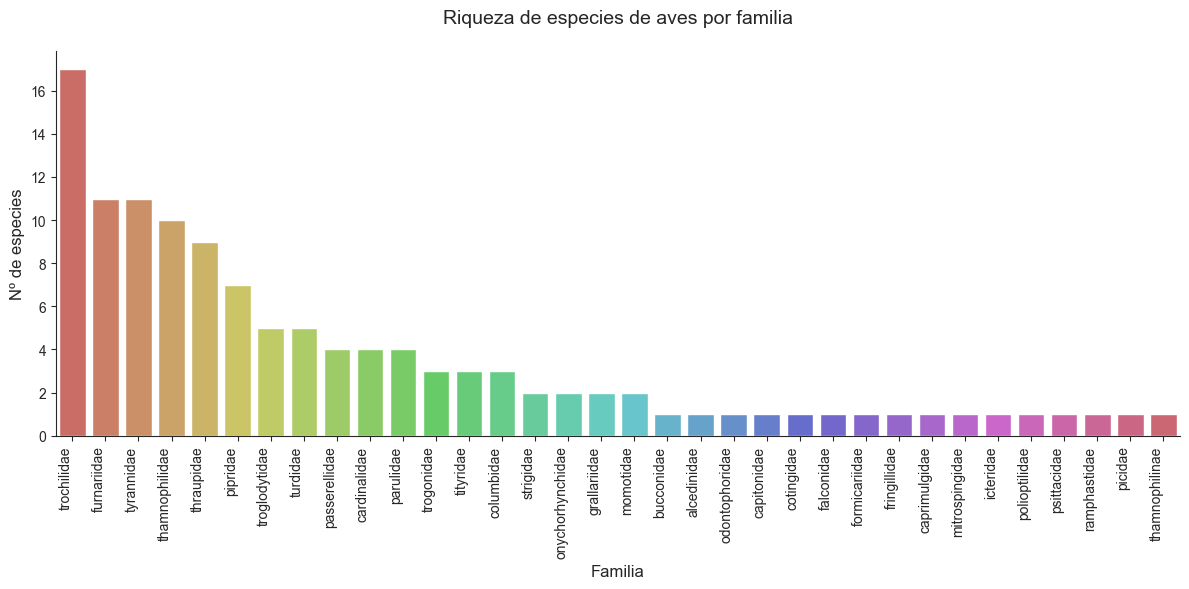

In [33]:
riqueza_familia = main_df.groupby("familia")["especie"].nunique().sort_values(ascending=False).reset_index()
#display(riqueza_familia)
#display(len(riqueza_familia[riqueza_familia["especie"]==1]))

plt.figure(figsize=(12, 6))
sns.set_style("ticks")

n_familias = len(riqueza_familia)
paleta = sns.color_palette("hls", n_familias)

r_f = sns.barplot(x="familia", y="especie", data=riqueza_familia, hue="familia",palette=paleta,legend=False)

plt.title("Riqueza de especies de aves por familia", fontsize=14, pad=20)
plt.xlabel("Familia", fontsize=12)
plt.ylabel("Nº de especies", fontsize=12)

#inclinacion de las etiquetas de cada fam para que se lean bien
plt.xticks(rotation=90, ha="right")
#sin margen
sns.despine()
#ajuste de ejes y titulos
plt.tight_layout()

plt.show()

### Bubble Charts: riqueza de spp de aves por familia y por categoria de distancia

In [34]:
'''
main_df = px.data.gapminder()

fig = px.scatter(main_df.query("familia"), x="distancia", y="riqueza_familia",
	         size="pop", color="distancia",
                 hover_name="familia", log_x=True, size_max=60)
fig.show()

'''

'\nmain_df = px.data.gapminder()\n\nfig = px.scatter(main_df.query("familia"), x="distancia", y="riqueza_familia",\n\t         size="pop", color="distancia",\n                 hover_name="familia", log_x=True, size_max=60)\nfig.show()\n\n'

In [35]:
# 1. Forzar el renderizado en el navegador para evitar el error de 'nbformat'
# Si ya instalaste nbformat y reiniciaste, puedes comentar la siguiente línea:
#pio.renderers.default = "browser"

# 2. Preparar los datos: Contamos capturas por especie en cada distancia
df_counts = main_df.groupby(["distancia", "familia", "especie"]).size().reset_index(name='capturas')

# 3. Ordenar por familia para que el eje Y sea legible
df_counts = df_counts.sort_values(["familia", "capturas"], ascending=[True, False])

# 4. Crear el Bubble Chart
fig = px.scatter(
    df_counts, 
    x="distancia", 
    y="familia", 
    size="capturas", 
    color="familia", 
    hover_name="especie",
    hover_data={"distancia": True, "familia": True, "capturas": True},
    title="Riqueza de Especies y Abundancia por Familia y Distancia",
    size_max=35,  # Tamaño máximo de la burbuja
    template="plotly_white"
)

# 5. El TRUCO: Como 'distancia' es categórica, las burbujas se enciman.
# Añadimos un pequeño desplazamiento (jitter) para ver las especies individuales
fig.update_traces(marker=dict(line=dict(width=1, color='DarkSlateGrey')))

# 6. Mejoras de diseño y dimensiones
fig.update_layout(
    xaxis_title="Categoría de Distancia",
    yaxis_title="Familia de Aves",
    height=900,         # Aumentamos la altura para que las familias no estén apretadas
    showlegend=False,    # Quitamos la leyenda porque ya tenemos los nombres en el eje Y
    margin=dict(l=150)   # Espacio para que los nombres de las familias no se corten
)

# 7. Ejecutar
fig.show()


In [36]:
# 1. Forzar el renderizado en el navegador para evitar el error de 'nbformat'
# Si ya instalaste nbformat y reiniciaste, puedes comentar la siguiente línea:
#pio.renderers.default = "browser"

# 2. Preparar los datos: Contamos capturas por especie en cada distancia
df_counts = main_df.groupby(["distancia", "familia", "especie"]).size().reset_index(name='capturas')

# 3. Ordenar por familia para que el eje Y sea legible
df_counts = df_counts.sort_values(["familia", "capturas"], ascending=[True, False])

# 4. Crear el Bubble Chart
fig = px.scatter(
    df_counts, 
    x="familia", 
    y="especie", 
    size="capturas", 
    color="distancia", 
    hover_name="especie",
    hover_data={"distancia": True, "familia": True, "capturas": True},
    title="Riqueza de Especies y Abundancia por Familia y Distancia",
    size_max=35,  # Tamaño máximo de la burbuja
    template="plotly_white"
)

# 5. El TRUCO: Como 'distancia' es categórica, las burbujas se enciman.
# Añadimos un pequeño desplazamiento (jitter) para ver las especies individuales
fig.update_traces(marker=dict(line=dict(width=1, color='DarkSlateGrey')))

# 6. Mejoras de diseño y dimensiones
fig.update_layout(
    xaxis_title="Categoría de Distancia",
    yaxis_title="Familia de Aves",
    height=900,         # Aumentamos la altura para que las familias no estén apretadas
    showlegend=False,    # Quitamos la leyenda porque ya tenemos los nombres en el eje Y
    margin=dict(l=150)   # Espacio para que los nombres de las familias no se corten
)

# 7. Ejecutar
fig.show()


### Riqueza de spp por familia y por distancia

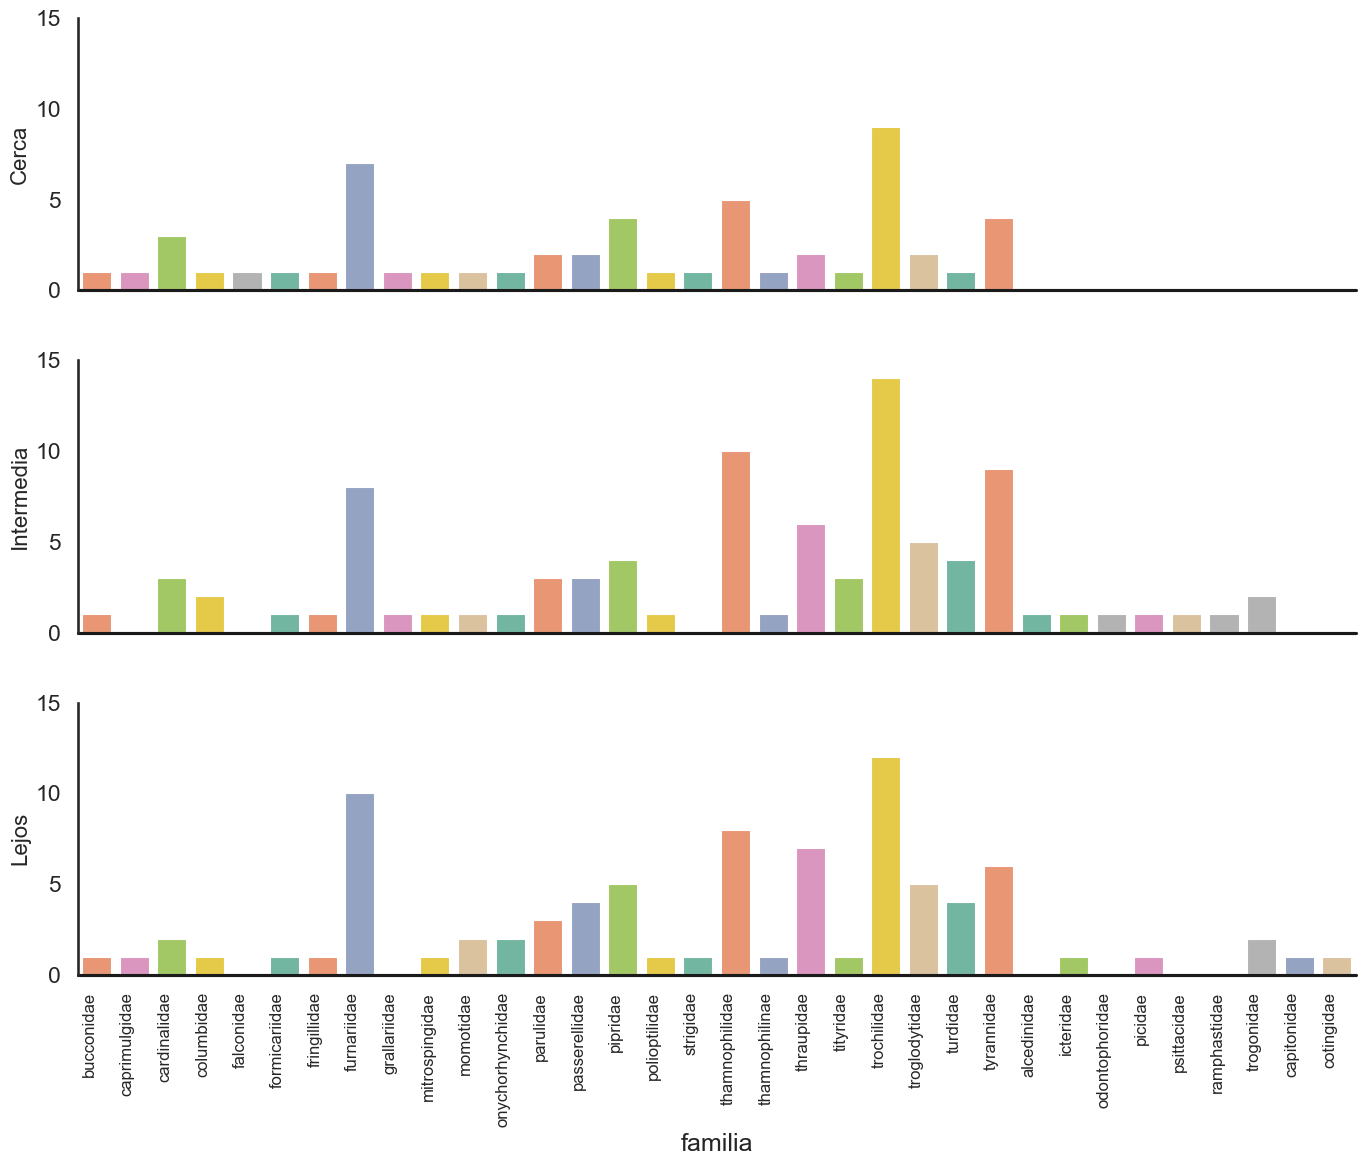

In [37]:
df_riqueza = main_df.groupby(["distancia", "familia"])["especie"].nunique().reset_index(name="riqueza")

familias_unicas = sorted(main_df["familia"].unique())

#'husl' o 'viridis' son buenas opciones.
colores = sns.color_palette("Set2", len(familias_unicas)) 
mapa_colores = dict(zip(familias_unicas, colores))

sns.set_theme(style="white", context="talk")
y_max = df_riqueza["riqueza"].max() + 1

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True, sharey=True)
axes = [ax1, ax2, ax3]
orden_distancia = ["cerca", "intermedia", "lejos"] 


for i, dist in enumerate(orden_distancia):
    data_subset = df_riqueza[df_riqueza["distancia"] == dist]
    
    sns.barplot(
        x="familia", 
        y="riqueza", 
        data=data_subset, 
        hue="familia", 
        palette=mapa_colores, 
        ax=axes[i],
        legend=False)
    
    axes[i].axhline(0, color="k", clip_on=False)
    axes[i].set_ylabel(dist.capitalize(), fontsize=16)
    axes[i].yaxis.get_major_locator().set_params(integer=True)
    axes[i].set_ylim(0, y_max)

sns.despine(bottom=True)
plt.xticks(rotation=90, ha="right", fontsize=12)
plt.tight_layout(h_pad=2)
plt.show()

### Plotly Riqueza de spp por familia y distancia

In [38]:
df_riqueza = main_df.groupby(["distancia", "familia"])["especie"].nunique().reset_index(name="riqueza")
familias_unicas = sorted(df_riqueza["familia"].unique())

color_sequence = px.colors.qualitative.Plotly_r + px.colors.qualitative.Prism

fig = px.bar(
    df_riqueza, 
    x="familia", 
    y="riqueza", 
    color="familia",
    facet_row="distancia",
    category_orders={"distancia": ["cerca", "intermedia", "lejos"]},
    color_discrete_sequence=color_sequence, # Punto 5: Colores únicos
    labels={"riqueza": "Nº de Especies (riqueza)", "familia": "Familia"},
    height=900)

# --- PERSONALIZACIÓN AVANZADA ---
#Centrar el título
fig.update_layout(
    title={
        "text": "Riqueza de especies por familia y distancia",
        "y": 0.98,
        "x": 0.5,
        "xanchor": "center",
        "yanchor": "top"},
    showlegend=False,
    margin=dict(l=100, r=20, t=80, b=150))

#Para Limpiar etiquetas de la derecha y moverlas a la izquierda
# quitarq los títulos automáticos de los ejes Y de cada subplot
fig.update_yaxes(title_text="") 

for anno in fig.layout.annotations:
    nueva_etiqueta = anno.text.split("=")[-1].capitalize()
    anno.text = nueva_etiqueta
    anno.x = -0.05 
    anno.textangle = -90

fig.add_annotation(
    dict(
        x=-0.08, y=0.5,
        showarrow=False,
        text="Nº de Especies (riqueza)",
        textangle=-90,
        xref="paper", yref="paper",
        font=dict(size=16)))

fig.update_xaxes(tickangle=-90, tickfont=dict(size=11))

fig.show()

# Guarda el gráfico en tu computadora
fig.write_html("riqueza_familias_interactivo.html")

In [39]:
'''
main_df.groupby(["familia"]).size().reset_index(name="n_especies")

#matriz de abundancia a nivel de familias
abundancia_familias= main_df.pivot(index="distancia", columns="familia", values="n_especies").fillna(0)

# 3. Creamos el gráfico
riq_= abundancia_familias.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')

# Estética del gráfico
plt.title('Riqueza de Especies por Familia y Distancia', fontsize=15)
plt.xlabel('Distancia a la Infraestructura', fontsize=12)
plt.ylabel('Número de Especies', fontsize=12)
plt.xticks(rotation=0) # Para que los nombres de abajo no estén de lado
plt.legend(title='Familias', bbox_to_anchor=(1.05, 1), loc='upper left') # Mueve la leyenda afuera

plt.tight_layout()
plt.show()
'''

'\nmain_df.groupby(["familia"]).size().reset_index(name="n_especies")\n\n#matriz de abundancia a nivel de familias\nabundancia_familias= main_df.pivot(index="distancia", columns="familia", values="n_especies").fillna(0)\n\n# 3. Creamos el gráfico\nriq_= abundancia_familias.plot(kind=\'bar\', stacked=True, figsize=(12, 7), colormap=\'viridis\')\n\n# Estética del gráfico\nplt.title(\'Riqueza de Especies por Familia y Distancia\', fontsize=15)\nplt.xlabel(\'Distancia a la Infraestructura\', fontsize=12)\nplt.ylabel(\'Número de Especies\', fontsize=12)\nplt.xticks(rotation=0) # Para que los nombres de abajo no estén de lado\nplt.legend(title=\'Familias\', bbox_to_anchor=(1.05, 1), loc=\'upper left\') # Mueve la leyenda afuera\n\nplt.tight_layout()\nplt.show()\n'

In [40]:
'''
main_df = main_df.groupby(["distancia", "familia"]).size().reset_index(name="n_especies")

#matriz de abundancia a nivel de familias
abundancia_familias= main_df.pivot(index="distancia", columns="familia", values="n_especies").fillna(0)

# 3. Creamos el gráfico
riq_= abundancia_familias.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')

# Estética del gráfico
plt.title('Riqueza de Especies por Familia y Distancia', fontsize=15)
plt.xlabel('Distancia a la Infraestructura', fontsize=12)
plt.ylabel('Número de Especies', fontsize=12)
plt.xticks(rotation=0) # Para que los nombres de abajo no estén de lado
plt.legend(title='Familias', bbox_to_anchor=(1.05, 1), loc='upper left') # Mueve la leyenda afuera

plt.tight_layout()
plt.show()

'''


'\nmain_df = main_df.groupby(["distancia", "familia"]).size().reset_index(name="n_especies")\n\n#matriz de abundancia a nivel de familias\nabundancia_familias= main_df.pivot(index="distancia", columns="familia", values="n_especies").fillna(0)\n\n# 3. Creamos el gráfico\nriq_= abundancia_familias.plot(kind=\'bar\', stacked=True, figsize=(12, 7), colormap=\'viridis\')\n\n# Estética del gráfico\nplt.title(\'Riqueza de Especies por Familia y Distancia\', fontsize=15)\nplt.xlabel(\'Distancia a la Infraestructura\', fontsize=12)\nplt.ylabel(\'Número de Especies\', fontsize=12)\nplt.xticks(rotation=0) # Para que los nombres de abajo no estén de lado\nplt.legend(title=\'Familias\', bbox_to_anchor=(1.05, 1), loc=\'upper left\') # Mueve la leyenda afuera\n\nplt.tight_layout()\nplt.show()\n\n'

## Transformar a Matriz de Abundancia

In [41]:
#pivotear df para que mis filas sean (localidad + distancia) y mis columnas las especie
#df_comunidad= main_df.groupby(['localidad', 'distancia', 'especie']).size().unstack(fill_value=0)

# Resetear índice para tener distancia como columna para los modelos
#df_abundancia = df_comunidad.reset_index()

df_abundancia = main_df.groupby(["localidad", "distancia", "año", "vuelta","especie"]).size().unstack(fill_value=0).reset_index()
#df_abundancia.rename(index={"especie":"replica_muestreo"},inplace=True)
df_abundancia.index.names=["replica_muestreo"]
display(df_abundancia)


#añadí año y vuelta para respetar el numero de repeticiones en el muestreo, a la hora de hacer la curva
#de acumulacion de spp se obtendrian mas de 30 filas y asi se tendrian mejores resultados.

especie,localidad,distancia,año,vuelta,aglaiocercus coelestis,amazilia amabilis,amazilia rosenbergi,amazilia tzacatl,androdon aequatorialis,arremon atricapillus,...,trogon comptus,trogon personatus,trogon rufus,turdus ignobilis,turdus obsoletus,urochroa bougueri,xenops minutus,xenops rutilans,xiphorhynchus erythropygius,zimmerius chrysops
replica_muestreo,,,,,,,,,,,,,,,,,,,,,
0,batea,lejos,2018,A,0,0,1,1,6,0,...,0,0,0,0,0,0,0,0,1,0
1,batea,lejos,2018,B,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,batea,lejos,2019,A,0,0,1,0,6,0,...,0,0,0,0,0,0,1,0,1,0
3,batea,lejos,2019,B,0,0,0,1,8,0,...,2,0,0,0,0,0,0,2,3,0
4,loca 1,cerca,2018,A,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
5,loca 1,cerca,2018,B,0,3,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
6,loca 1,cerca,2019,A,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,2,0
7,loca 1,cerca,2019,B,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
8,loca 2,cerca,2018,A,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Cálculo diversidad Alfa (¿Cuántas hay y cómo están repartidas?)

### Cálculo números de Hill:

In [42]:

def numeros_hill(fila, q): #donde q es las especies que hay por fila
    #p=abundancia relativa, por lo que se quieren las especies que tuvieron uno o mas registros.
    p = fila[fila > 0] / fila.sum()#y la sum vendria siendo el total de spp en ese sitio
    
    if q == 0:# Riqueza: especies que se encontraron 1 o mas veces (p>0)
        return len(p)  
    elif q == 1:# Exp de Shannon
        return np.exp(-np.sum(p * np.log(p)))  
    elif q == 2:
        return 1 / np.sum(p**2)  # Inverso de Simpson

sin_columnas = ["localidad", "distancia", "año", "vuelta","q0", "q1", "q2"]
df_abundancia_sin_columnas= df_abundancia.drop(
        columns=[col for col in sin_columnas if col in df_abundancia.columns])

# Aplicar a cada fila de nuestra matriz
spp_columnas= df_abundancia.columns
df_abundancia["q0"] = df_abundancia_sin_columnas.apply(lambda r: numeros_hill(r, 0), axis=1).values
df_abundancia["q1"] = df_abundancia_sin_columnas.apply(lambda r: numeros_hill(r, 1), axis=1).values
df_abundancia["q2"] = df_abundancia_sin_columnas.apply(lambda r: numeros_hill(r, 2), axis=1).values

display(df_abundancia[["localidad", "distancia", "año", "vuelta","q0", "q1", "q2"]])


especie,localidad,distancia,año,vuelta,q0,q1,q2
replica_muestreo,,,,,,,
0,batea,lejos,2018,A,43,27.586922,19.830986
1,batea,lejos,2018,B,22,19.792619,17.307692
2,batea,lejos,2019,A,32,21.445035,15.796053
3,batea,lejos,2019,B,37,22.603756,15.598017
4,loca 1,cerca,2018,A,25,20.707837,17.340206
5,loca 1,cerca,2018,B,16,14.719574,13.444444
6,loca 1,cerca,2019,A,25,20.945027,17.600000
7,loca 1,cerca,2019,B,30,22.851014,18.000000
8,loca 2,cerca,2018,A,25,18.800879,14.500000


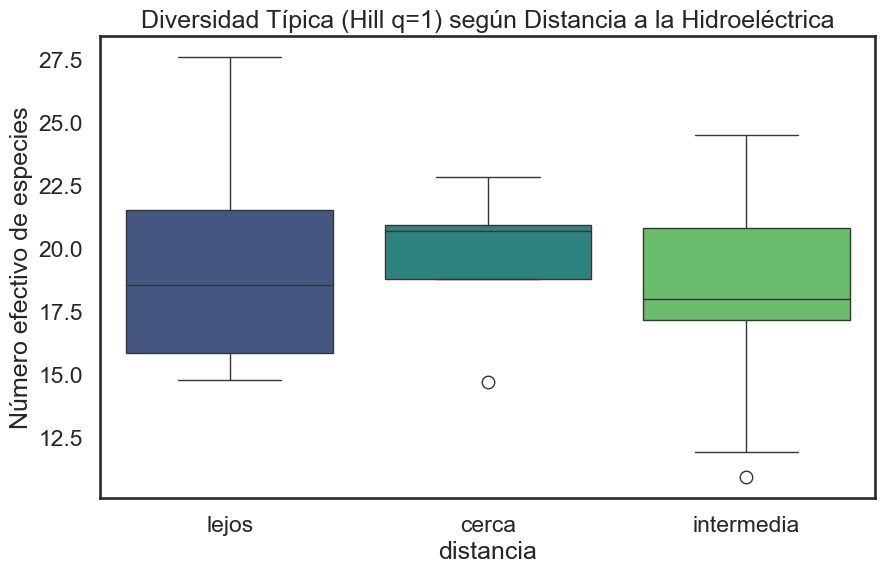

In [43]:
plt.figure(figsize=(10,6))
sns.boxplot(x="distancia", y="q1", data=df_abundancia.reset_index(), palette="viridis", hue="distancia",legend=False)
plt.title("Diversidad Típica (Hill q=1) según Distancia a la Hidroeléctrica")
plt.ylabel("Número efectivo de especies")
plt.show()

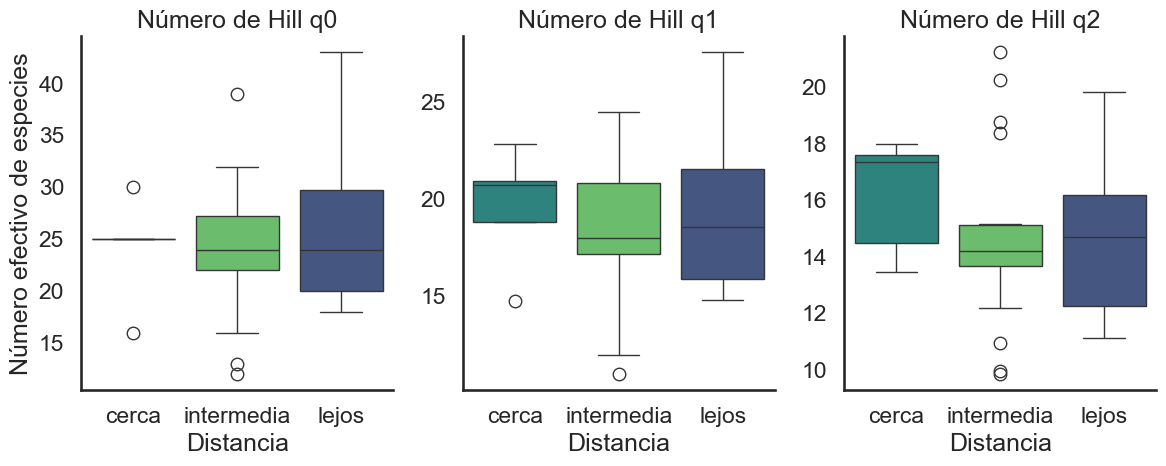

In [44]:
orden_distancia = ["cerca", "intermedia", "lejos"]

df_melt = df_abundancia.melt(id_vars=['distancia'], 
                             value_vars=['q0', 'q1', 'q2'], 
                             var_name='Num_Hill', 
                             value_name='Valor')

g = sns.FacetGrid(df_melt, col="Num_Hill", sharey=False, height=5, aspect=0.8)

g.map_dataframe(sns.boxplot, 
                x="distancia", 
                y="Valor", 
                palette="viridis", 
                hue="distancia", 
                order=orden_distancia) # <--- AQUÍ SE DEFINE EL ORDEN

g.set_titles("Número de Hill {col_name}")
g.set_axis_labels("Distancia", "Número efectivo de especies")
plt.tight_layout()
plt.show()

### GML: modelo lineal generalizado

evidencia si la variable distancia explica de forma estadísticamente significativa la caída o subida de la diversidad.

In [45]:
modelo_q0 = smf.glm(formula="q0 ~ distancia", 
                    data=df_abundancia, 
                    family=sm.families.Poisson()).fit()

# 2. Modelo para q1 (Diversidad Shannon - Distribución Gaussiana/Normal)
modelo_q1 = smf.glm(formula="q1 ~ distancia", 
                    data=df_abundancia, 
                    family=sm.families.Gaussian()).fit()

# 3. Modelo para q2 (Diversidad Simpson - Distribución Gaussiana/Normal)
modelo_q2 = smf.glm(formula="q2 ~ distancia", 
                    data=df_abundancia, 
                    family=sm.families.Gaussian()).fit()

# Mostrar resúmenes
print("--- RESULTADOS Q0 ---")
display(modelo_q0.summary())

print("--- RESULTADOS Q1 ---")
display(modelo_q1.summary())

print("--- RESULTADOS Q2 ---")
display(modelo_q2.summary())

--- RESULTADOS Q0 ---


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                     q0   No. Observations:                   37
Model:                            GLM   Df Residuals:                       34
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -123.48
Date:                Wed, 18 Mar 2026   Deviance:                       61.162
Time:                        10:27:18   Pearson chi2:                     61.3
No. Iterations:                     4   Pseudo R-squ. (CS):            0.03464
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   3.1864      0.091     35.050      0.000       3.008       3.365
distancia[T.intermedia]    -0.0021      0.102     -0.020      0.984      -0.201       0.197
distancia[T.lejos]          0.0781      0.107      0.730      0.465      -0.132       0.288
===========================================================================================
"""

--- RESULTADOS Q1 ---


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                     q1   No. Observations:                   37
Model:                            GLM   Df Residuals:                       34
Model Family:                Gaussian   Df Model:                            2
Link Function:               Identity   Scale:                          14.860
Method:                          IRLS   Log-Likelihood:                -100.86
Date:                Wed, 18 Mar 2026   Deviance:                       505.24
Time:                        10:27:18   Pearson chi2:                     505.
No. Iterations:                     3   Pseudo R-squ. (CS):            0.01531
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  19.6049      1.724     11.372      0.000      16.226      22.984
distancia[T.intermedia]    -1.1600      1.927     -0.602      0.547      -4.938       2.618
distancia[T.lejos]         -0.5450      2.052     -0.266      0.791      -4.567       3.477
===========================================================================================
"""

--- RESULTADOS Q2 ---


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                     q2   No. Observations:                   37
Model:                            GLM   Df Residuals:                       34
Model Family:                Gaussian   Df Model:                            2
Link Function:               Identity   Scale:                          8.1621
Method:                          IRLS   Log-Likelihood:                -89.777
Date:                Wed, 18 Mar 2026   Deviance:                       277.51
Time:                        10:27:18   Pearson chi2:                     278.
No. Iterations:                     3   Pseudo R-squ. (CS):            0.03546
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  16.1769      1.278     12.661      0.000      13.673      18.681
distancia[T.intermedia]    -1.5040      1.428     -1.053      0.292      -4.304       1.296
distancia[T.lejos]         -1.5183      1.521     -0.998      0.318      -4.499       1.462
===========================================================================================
"""

## Cálculo diversidad Beta

Mientras que la Diversidad Alfa nos decía cuántas especies hay, la Beta nos dice si las especies en "Cerca" son las mismas que en "Lejos". La diversidad alfa habla de "cuantas" mientras que la beta habla de "quienes"

### Calcular Distancias y Ordenación
Aquí comparamos cada sitio con todos los demás. Si dos sitios comparten muchas especies en proporciones similares, su distancia será pequeña (cercana a 0).

In [46]:
bray_curtis= beta_diversity("braycurtis", df_abundancia_sin_columnas.values, ids=df_abundancia.index)

#PCoA (Ordenación) -> reduce todas las spp a solo 2 ejes principales
pcoa_resultados= pcoa(bray_curtis)

coordenadas = pcoa_resultados.samples[["PC1", "PC2"]]
coordenadas = coordenadas.reset_index()


df_coordenadas_abundacia = pd.merge(coordenadas, 
    df_abundancia[["distancia"]].reset_index(drop=True), 
    left_index=True, 
    right_index=True)

df_coordenadas_abundacia

c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\skbio\stats\ordination\_principal_coordinate_analysis.py:164: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(
c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\skbio\stats\ordination\_principal_coordinate_analysis.py:282: RuntimeWarning: The result contains negative eigenvalues that are large in magnitude, which may suggest result inaccuracy. See Notes for details. The negative-most eigenvalue is -0.06391965181798126 whereas the largest positive one is 1.3694319330377132.
  warn(


,index,PC1,PC2,distancia
0,0,0.346922,-0.162419,lejos
1,1,-0.042100,0.138027,lejos
2,2,0.305588,-0.102428,lejos
3,3,0.337757,-0.163727,lejos
4,4,-0.118619,-0.196068,cerca
5,5,-0.305097,0.143277,cerca
6,6,-0.160777,-0.125661,cerca
7,7,-0.073822,-0.154323,cerca
8,8,-0.001190,-0.063708,cerca
9,9,-0.030739,-0.111313,intermedia


### Grafico PCoA

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10636\4189621466.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.xlabel(f"PC1 ({pcoa_resultados.proportion_explained[0]*100:.1f}%)")
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10636\4189621466.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.ylabel(f"PC2 ({pcoa_resultados.proportion_explained[1]*100:.1f}%)")


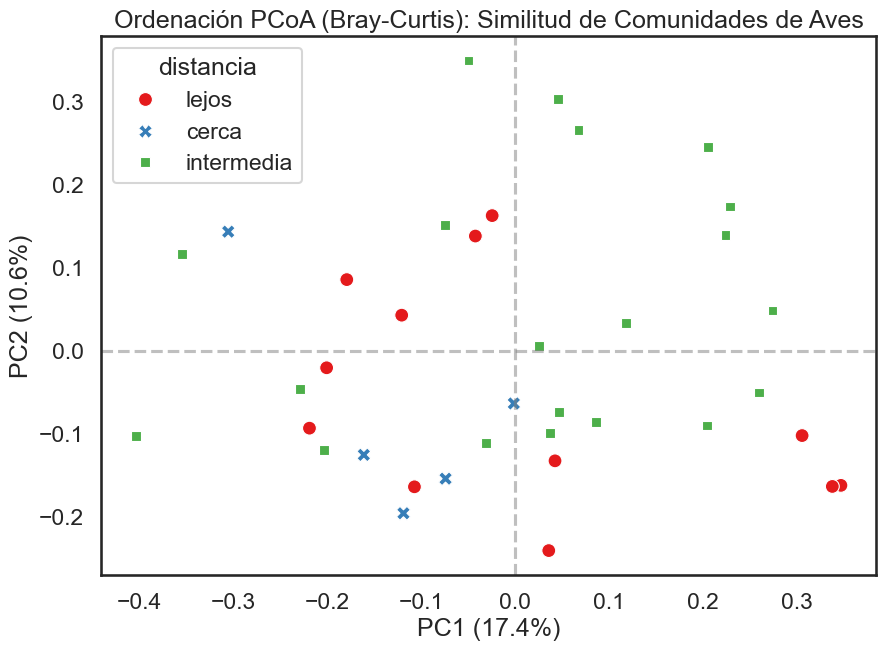

In [47]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_coordenadas_abundacia, 
                x="PC1", y="PC2", hue="distancia", style="distancia", s=100, palette="Set1")

# Añadimos etiquetas de los ejes con el porcentaje de variación explicada
plt.xlabel(f"PC1 ({pcoa_resultados.proportion_explained[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pcoa_resultados.proportion_explained[1]*100:.1f}%)")
plt.title("Ordenación PCoA (Bray-Curtis): Similitud de Comunidades de Aves")
plt.axhline(0, color="grey", linestyle="--", alpha=0.5)
plt.axvline(0, color="grey", linestyle="--", alpha=0.5)
plt.show()

### PERMANOVA

In [48]:
# Comprobamos si las diferencias en el gráfico son significativas
resultado_permanova = permanova(bray_curtis, df_abundancia["distancia"])
display(resultado_permanova)

method name               PERMANOVA
test statistic name        pseudo-F
sample size                      37
number of groups                  3
test statistic             1.578556
p-value                       0.021
number of permutations          999
Name: PERMANOVA results, dtype: object

## Análisis de Especies Indicadoras (IndVal)

In [49]:
#abundancia promedio de cada especie por categoría de distancia
spp_indicadoras = df_abundancia.groupby("distancia")[df_abundancia_sin_columnas.columns].mean().T

columnas_numericas = spp_indicadoras.columns # Son 'cerca', 'medio', 'lejos'

#spp que "prefieren" estar Cerca vs Lejos
#columna que diga dónde es más abundante cada spp
spp_indicadoras["preferencia"] = spp_indicadoras[columnas_numericas].idxmax(axis=1)
spp_indicadoras["abundancia_maxima"]= spp_indicadoras[columnas_numericas].max(axis=1)

#spp representativas --> tienen más de 2 capturas promedio
top_indicadoras = spp_indicadoras[spp_indicadoras["abundancia_maxima"] > 2].sort_values(by="preferencia")

print("--- ESPECIES QUE DEFINEN CADA ZONA ---")
display(top_indicadoras[["preferencia", "abundancia_maxima"]])



--- ESPECIES QUE DEFINEN CADA ZONA ---


distancia,preferencia,abundancia_maxima
especie,,
dixiphia pipra,cerca,3.400000
microbates cinereiventris,cerca,2.400000
schiffornis veraepacis,cerca,2.400000
chlorothraupis stolzmanni,intermedia,3.650000
eutoxeres aquila,intermedia,5.050000
thalurania colombica,intermedia,2.250000
euphonia xanthogaster,lejos,3.500000
glyphorynchus spirurus,lejos,6.083333
mionectes olivaceus,lejos,7.666667


In [50]:
#top_indicadoras.sort_values("abundancia_maxima")
top_indicadoras[["preferencia", "abundancia_maxima"]].sort_values("abundancia_maxima")


distancia,preferencia,abundancia_maxima
especie,,
thalurania colombica,intermedia,2.250000
threnetes ruckeri,lejos,2.333333
schiffornis veraepacis,cerca,2.400000
microbates cinereiventris,cerca,2.400000
dixiphia pipra,cerca,3.400000
euphonia xanthogaster,lejos,3.500000
chlorothraupis stolzmanni,intermedia,3.650000
tachyphonus delatrii,lejos,4.333333
phaethornis yaruqui,lejos,4.666667


In [51]:
display(main_df["especie"].value_counts().sort_values())
#las spp con una sola captura deben tener esa caracteristica

especie
pipreola jucunda            1
claravis pretiosa           1
micrastur ruficollis        1
megascops ingens            1
lepidothrix coronata        1
                         ... 
euphonia xanthogaster     111
glyphorynchus spirurus    160
eutoxeres aquila          163
phaethornis yaruqui       169
mionectes olivaceus       188
Name: count, Length: 120, dtype: int64

## curva de acumulación de especies:

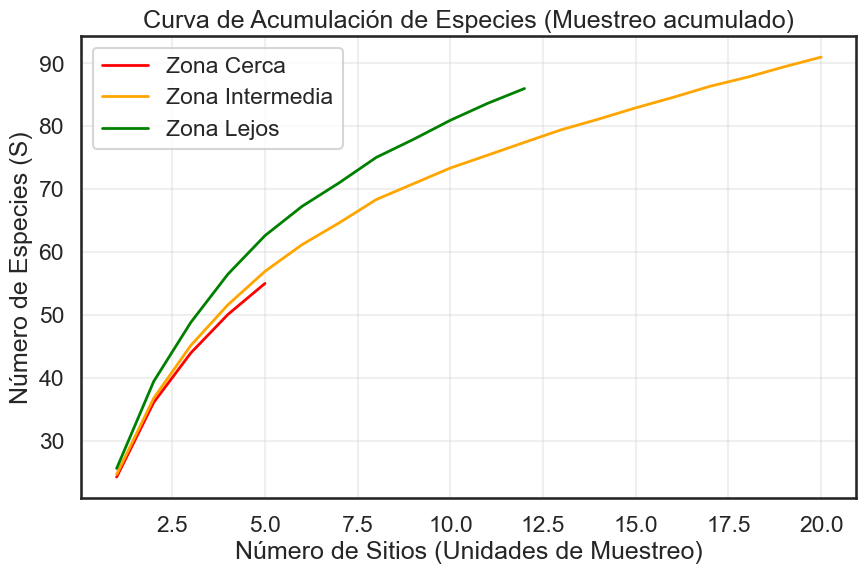

In [52]:
def calcular_curva_acumulacion(matriz, permutaciones=100):
    n_sitios = matriz.shape[0]#filas por localidad
    matriz_pa = (matriz > 0).astype(int)#matriz de presencia (1) y ausencia (0)
    resultados_perm = []
    
    for a in range(permutaciones):
        matriz_azar = matriz_pa.sample(frac=1).values
        acumulada = []
        for i in range(1, n_sitios + 1):
            s_acumulada = (matriz_azar[:i].sum(axis=0) > 0).sum()
            acumulada.append(s_acumulada)
        resultados_perm.append(acumulada)
    
    return np.mean(resultados_perm, axis=0)


plt.figure(figsize=(10, 6))
colores = {"cerca": "red", "intermedia": "orange", "lejos": "green"}

for cat in ["cerca", "intermedia", "lejos"]:
    # Filtramos los datos de la categoría
    datos_cat = df_abundancia[df_abundancia["distancia"] == cat][df_abundancia_sin_columnas.columns]
    
    if len(datos_cat) > 0:
        curva = calcular_curva_acumulacion(datos_cat)
        plt.plot(range(1, len(curva) + 1), curva, label=f'Zona {cat.capitalize()}', 
                 color=colores[cat], lw=2)

plt.title('Curva de Acumulación de Especies (Muestreo acumulado)')
plt.xlabel('Número de Sitios (Unidades de Muestreo)')
plt.ylabel('Número de Especies (S)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

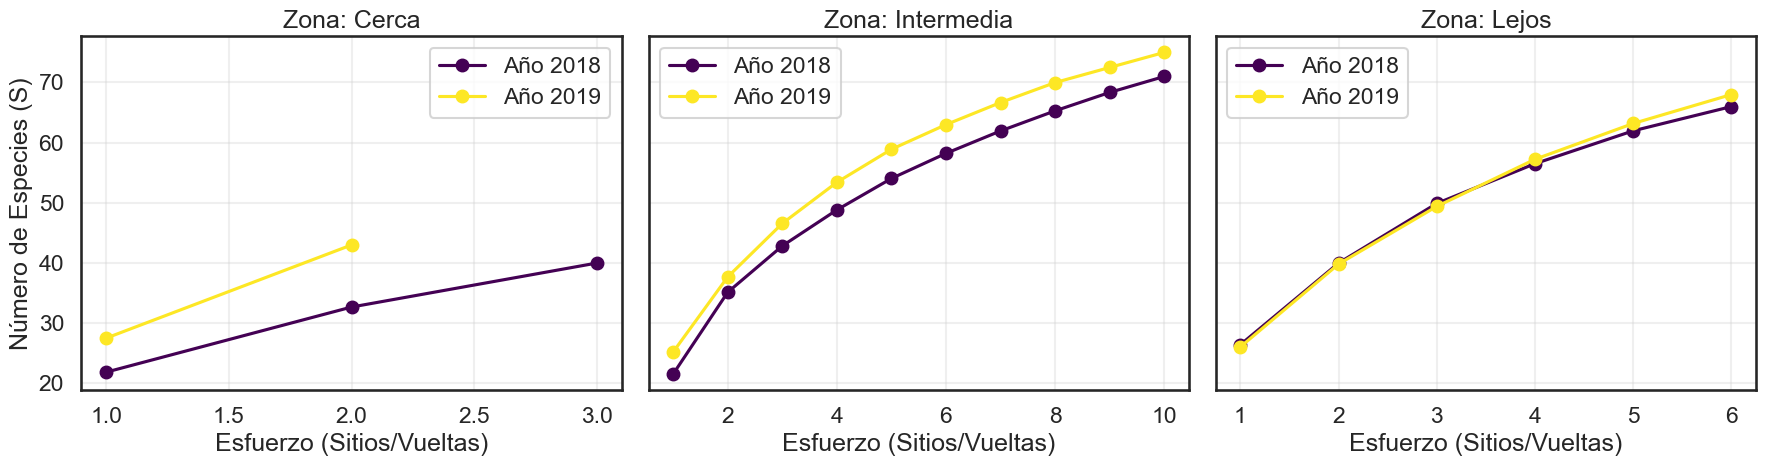

In [53]:
# 1. Definimos las zonas y los años únicos que tienes en el DataFrame
zonas = ["cerca", "intermedia", "lejos"]
años = df_abundancia["año"].unique()  # Asegúrate de que la columna se llame "año"

# 2. Creamos una figura con 3 subplots (uno para cada zona)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, cat in enumerate(zonas):
    ax = axes[i]
    # Colores por año para diferenciar dentro de la misma zona
    colores_año = plt.cm.viridis(np.linspace(0, 1, len(años)))
    
    for j, año in enumerate(años):
        # FILTRAMOS: por zona Y por año
        datos_filt = df_abundancia[(df_abundancia["distancia"] == cat) & (df_abundancia["año"] == año)]
        
        # Extraemos solo las columnas de especies
        especies_cols = df_abundancia_sin_columnas.columns
        matriz_final = datos_filt[especies_cols]
        
        if len(matriz_final) > 1: # Necesitamos al menos 2 sitios para hacer una curva
            curva = calcular_curva_acumulacion(matriz_final)
            ax.plot(range(1, len(curva) + 1), curva, 
                    label=f'Año {año}', color=colores_año[j], marker='o')
    
    ax.set_title(f'Zona: {cat.capitalize()}')
    ax.set_xlabel('Esfuerzo (Sitios/Vueltas)')
    if i == 0: ax.set_ylabel('Número de Especies (S)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [54]:
# Conteo de sitios y especies por distancia
for cat in df_abundancia["distancia"].unique():
    datos_cat = df_abundancia[df_abundancia["distancia"] == cat][df_abundancia_sin_columnas.columns]
    n_sitios = len(datos_cat)
    n_especies = (datos_cat.sum(axis=0) > 0).sum()
    print(f"Distancia: {cat} | Sitios: {n_sitios} | Especies Totales: {n_especies}")

Distancia: lejos | Sitios: 12 | Especies Totales: 86
Distancia: cerca | Sitios: 5 | Especies Totales: 55
Distancia: intermedia | Sitios: 20 | Especies Totales: 91


## grafica de riqueza observada vs riqueza estimada (chao1):

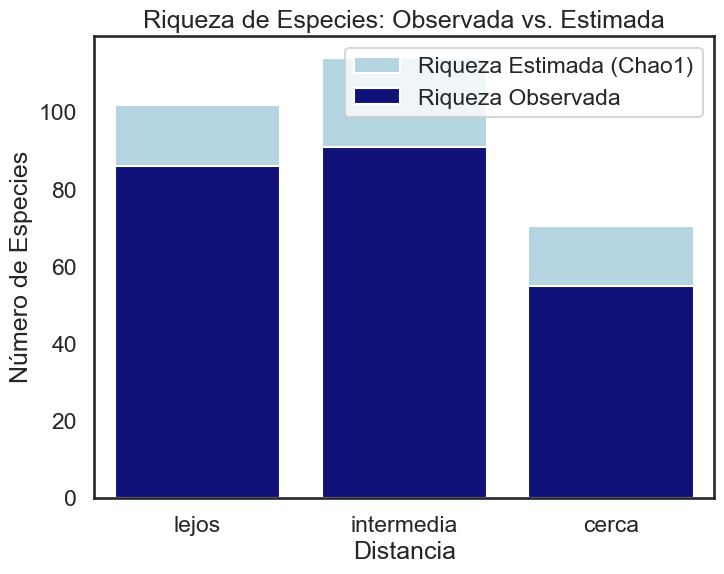

In [55]:
# Calculamos Chao1 para cada zona
stats = []
for cat in ['lejos', 'intermedia', 'cerca']:
    zona = df_abundancia[df_abundancia['distancia'] == cat][df_abundancia_sin_columnas.columns].sum()
    stats.append({
        'Distancia': cat,
        'Observada': (zona > 0).sum(),
        'Estimada (Chao1)': chao1(zona)
    })

df_stats = pd.DataFrame(stats)

# Graficamos
plt.figure(figsize=(8, 6))
sns.barplot(data=df_stats, x='Distancia', y='Estimada (Chao1)', color='lightblue', label='Riqueza Estimada (Chao1)')
sns.barplot(data=df_stats, x='Distancia', y='Observada', color='darkblue', label='Riqueza Observada')

plt.title('Riqueza de Especies: Observada vs. Estimada')
plt.ylabel('Número de Especies')
plt.legend()
plt.show()

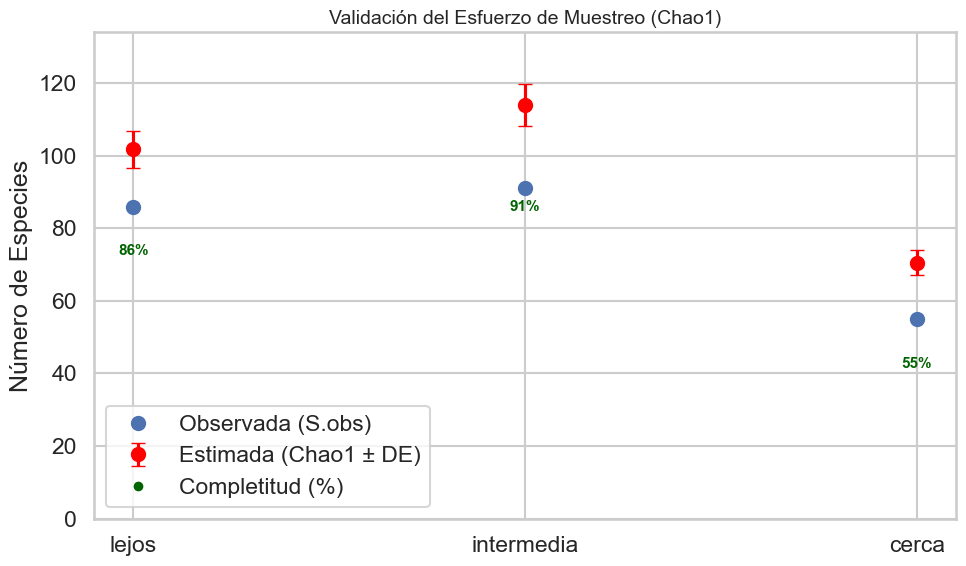

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines # Importamos esto para la leyenda personalizada

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# 1. Graficar Estimada
plt.errorbar(x=df_stats['Distancia'], y=df_stats['Estimada (Chao1)'], 
             yerr=df_stats['Estimada (Chao1)']*0.05, fmt='o', color='red', 
             label='Estimada (Chao1 ± DE)', markersize=10, capsize=5)

# 2. Graficar Observada
plt.plot(df_stats['Distancia'], df_stats['Observada'], 'bo', 
         label='Observada (S.obs)', markersize=10)

# 3. Etiquetas de texto sobre los puntos (tu código original)
for i, row in df_stats.iterrows():
    plt.text(i, row['Estimada (Chao1)'] - 30, f"{row['Observada']}%", 
             ha='center', va='bottom', fontsize=11, fontweight='bold', color='darkgreen')
    

# --- EL TRUCO PARA LA LEYENDA ---
# Creamos un objeto "fantasma" que represente el % de completitud
completitud_patch = mlines.Line2D([], [], color='white', marker='o', 
                                  markerfacecolor='darkgreen', markersize=8, 
                                  label='Completitud (%)')

# Obtenemos los handles y labels actuales y añadimos el nuevo
handles, labels = plt.gca().get_legend_handles_labels()
handles.append(completitud_patch)

plt.legend(handles=handles)
# -------------------------------

plt.title('Validación del Esfuerzo de Muestreo (Chao1)', fontsize=14)
plt.ylabel('Número de Especies')
plt.ylim(0, df_stats['Estimada (Chao1)'].max() + 20)

plt.tight_layout()
plt.show()

In [59]:
print(df_stats.columns.tolist())


['Distancia', 'Observada', 'Estimada (Chao1)']


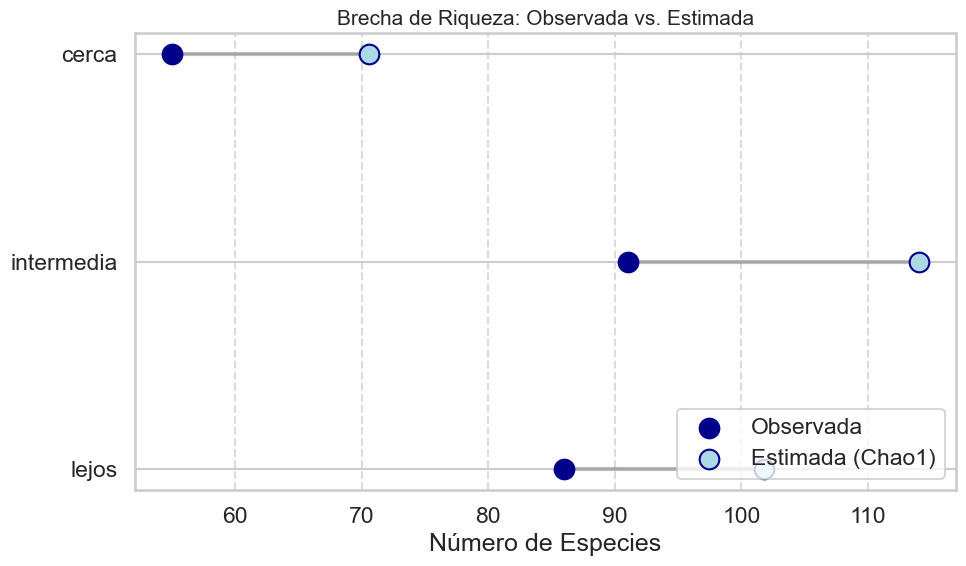

In [57]:
plt.figure(figsize=(10, 6))

# Dibujamos las líneas que unen los puntos
plt.hlines(y=df_stats['Distancia'], xmin=df_stats['Observada'], 
           xmax=df_stats['Estimada (Chao1)'], color='grey', alpha=0.5, linewidth=3)

# Dibujamos los puntos de Observada
plt.scatter(df_stats['Observada'], df_stats['Distancia'], 
            color='darkblue', s=200, label='Observada', zorder=3)

# Dibujamos los puntos de Estimada
plt.scatter(df_stats['Estimada (Chao1)'], df_stats['Distancia'], 
            color='lightblue', s=200, label='Estimada (Chao1)', edgecolors='darkblue', zorder=3)

plt.title('Brecha de Riqueza: Observada vs. Estimada', fontsize=15)
plt.xlabel('Número de Especies')
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [58]:
# Esto nos dirá exactamente cuántas filas hay por cada nombre escrito en 'distancia'
print("--- CONTEO DETALLADO DE FILAS POR CATEGORÍA ---")
print(df_abundancia['distancia'].value_counts())

print("\n--- ¿CÓMO SE VEN LOS NOMBRES REALMENTE? ---")
print(df_abundancia['distancia'].unique().tolist())

--- CONTEO DETALLADO DE FILAS POR CATEGORÍA ---
distancia
intermedia    20
lejos         12
cerca          5
Name: count, dtype: int64

--- ¿CÓMO SE VEN LOS NOMBRES REALMENTE? ---
['lejos', 'cerca', 'intermedia']


In [ ]:
print("Nuevo conteo de sitios por distancia:")
print(df_abundancia['distancia'].value_counts())

In [ ]:
# Filtramos la matriz de abundancia para ver solo las filas de 'lejos'
verificacion_lejos = df_abundancia[df_abundancia['distancia'] == 'lejos']

print("--- FILAS DETECTADAS COMO 'LEJOS' ---")
display(verificacion_lejos)

# Si tienes una columna llamada 'localidad', veamos cuántas hay
if 'localidad' in df_abundancia.columns:
    print("\nLocalidades encontradas en la zona Lejos:")
    print(verificacion_lejos['localidad'].unique())

In [ ]:
# Suma total en el Excel original
total_original = len(main_df) 

# Suma total en la matriz de abundancia (solo columnas de especies)
total_matriz = df_abundancia[df_abundancia_sin_columnas.columns].values.sum()

print(f"Total registros Excel: {total_original}")
print(f"Total registros Matriz: {total_matriz}")

if total_original == total_matriz:
    print("✅ ¡Perfecto! No se perdió ni un solo pájaro.")
else:
    print("❌ Hay una diferencia. Revisa si eliminaste valores nulos (NaN).")

## Rarefraccion:

In [ ]:
def rarefaccion_individuos(abundancias, paso=10):
    """Calcula la riqueza esperada al ir extrayendo n individuos al azar"""
    total_ind = int(sum(abundancias))
    especies = np.array(abundancias)
    especies = especies[especies > 0] # Solo especies presentes
    
    x_vals = range(1, total_ind + 1, paso)
    y_vals = []
    
    for n in x_vals:
        # Fórmula de Hurlbert para rarefacción
        # Probabilidad de que una especie NO esté en una submuestra de tamaño n
        # S_n = Suma(1 - [Comb(N-Ni, n) / Comb(N, n)])
        # Aquí usamos una simulación simplificada por rendimiento:
        riqueza_esperada = 0
        for ni in especies:
            if n > (total_ind - ni):
                riqueza_esperada += 1
            else:
                # Aproximación probabilística
                riqueza_esperada += 1 - np.exp(np.log(1 - ni/total_ind) * n)
        y_vals.append(riqueza_esperada)
        
    return list(x_vals), y_vals

# --- Graficación ---
plt.figure(figsize=(10, 6))
colores = {'lejos': 'green', 'intermedia': 'orange', 'cerca': 'red'}

for cat in ['lejos', 'intermedia', 'cerca']:
    # Sumamos todos los individuos de todas las especies para esa distancia
    datos_zona = df_abundancia[df_abundancia['distancia'] == cat][df_abundancia_sin_columnas.columns].sum()
    
    x, y = rarefaccion_individuos(datos_zona)
    plt.plot(x, y, label=f'Zona: {cat}', color=colores[cat], lw=2)
    # Dibujamos un punto al final para marcar el total real observado
    plt.scatter(x[-1], y[-1], color=colores[cat], s=50)

plt.title('Curvas de Rarefacción (Basadas en Individuos)')
plt.xlabel('Número de Individuos Muestreados')
plt.ylabel('Riqueza de Especies Esperada')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Conteo simple por categoría de distancia
resumen_distancia = main_df['distancia'].value_counts().reset_index()
resumen_distancia.columns = ['Distancia', 'Total de Capturas']

display(resumen_distancia)

In [ ]:
tabla_limpia = main_df.groupby(['distancia', 'localidad']).size().reset_index(name='Capturas')

display(tabla_limpia)